## Feature Engineering

In this section we aggregate the dataset and engineer new features so that it can be used as the input for our prediction models

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from pathlib import Path
import sys
import os
import holidays


path = os.getcwd()
while ".git" not in os.listdir(path):
    path = os.path.dirname(path)
ROOT_DIR = Path(path)
os.chdir(ROOT_DIR)

from scripts.helpers.datasets import load_taxi_data

In [2]:
df = load_taxi_data(preprocessed=True)

## Demand Panel — Forecasting Target (Hexagon × Time Bucket)

Task 3 forecasts **demand per spatial unit and time bucket**, so the modelling unit is no longer an individual trip but a *(hexagon, time-slot)* cell. We therefore aggregate the trip table into a **demand panel**: one row per `(h3_id, time_bucket)` whose `trip_count` (number of pickups) is the prediction target shared by both the SVM and the neural network. This step lives in feature engineering rather than in a single model notebook precisely because that target definition must be identical across both models.

Two design choices matter for correctness:

- **Pickup = demand.** We count trips by their *origin* hexagon (`pickup_h3_r{res}`); dropoffs measure attraction, which is a different quantity.
- **Complete grid with zero-fill.** A plain `groupby().size()` only emits cells that actually saw a trip, but a hexagon-hour with *zero* pickups is a real demand observation. `build_demand_panel` reindexes onto the full *(hexagon × time-bucket)* grid and fills the missing slots with `0` — otherwise the models would only ever see non-zero demand and systematically over-predict.

The builder is **generic in both axes**: `resolution` sets the H3 spatial unit and `freq` (a pandas offset alias such as `'1h'`, `'4h'`, `'1D'`) sets the bucket width, and the same `freq` drives both the bucketing and the zero-fill grid so the two can never drift apart. This lets us run a sensitivity sweep over granularity simply by looping over the two parameters. We default to **resolution 7, hourly** — the primary unit established in the descriptive analysis as the balance between spatial detail and sufficient trips per cell.

One downstream consequence: because the panel is an ordered time series, the train/validation/test split below must be **chronological**, not random — a random split would leak future demand into training through temporal autocorrelation and any lag features.

In [3]:
from scripts.helpers.spatial import add_h3_cells, build_demand_panel

# Spatial / temporal granularity (primary unit from the descriptive analysis).
RESOLUTION = 6      # H3 resolution  -> spatial unit
FREQ       = "3h"   # time-bucket width (pandas offset alias: '1h', '4h', '1D', ...)

# Assign each trip to its pickup H3 cell if not already present.
if f"pickup_h3_r{RESOLUTION}" not in df.columns:
    add_h3_cells(df, RESOLUTION)

# Aggregate to the complete (hexagon x time-bucket) demand panel (zero-filled).
panel = build_demand_panel(df, resolution=RESOLUTION, freq=FREQ, spatial_role="pickup")

zero_share = (panel["trip_count"] == 0).mean()
print(f"Panel: {panel.shape[0]:,} rows  ({panel['h3_id'].nunique()} hexagons x "
      f"{panel['time_bucket'].nunique()} buckets)  |  zero-demand slots: {zero_share:.1%}")
panel.head()

Panel: 177,008 rows  (26 hexagons x 6808 buckets)  |  zero-demand slots: 76.1%


,h3_id,time_bucket,trip_count
0,862664197ffffff,2024-01-01 00:00:00,0
1,862664197ffffff,2024-01-01 03:00:00,0
2,862664197ffffff,2024-01-01 06:00:00,0
3,862664197ffffff,2024-01-01 09:00:00,0
4,862664197ffffff,2024-01-01 12:00:00,0


In [4]:
# Sanity check: every trip must be counted exactly once in the panel
# (no trips dropped, none double-counted). This guards against bucketing bugs
# such as tz/DST grid drift, which silently lose trips at multi-hour FREQ.
hex_col   = f"pickup_h3_r{RESOLUTION}"
n_valid   = df[[hex_col, "trip_start_timestamp"]].dropna().shape[0]
n_counted = int(panel["trip_count"].sum())

print(f"Trips counted in panel : {n_counted:,}")
print(f"Valid trips in dataframe: {n_valid:,}")
assert n_counted == n_valid, (
    f"Trip count mismatch: {n_counted:,} != {n_valid:,} (trips lost or double-counted)"
)
print("OK - all trips accounted for exactly once.")

Trips counted in panel : 5,891,622
Valid trips in dataframe: 5,891,622
OK - all trips accounted for exactly once.


### Granularity Sensitivity — Panel Sparsity

The spatial resolution and time-bucket width are a **trade-off**: finer granularity localizes demand more precisely but makes the panel sparser — more zero-demand `(hexagon, bucket)` slots — which is harder to learn and pushes the target toward zero-inflation. The heatmap below sweeps both axes and reports the share of zero-demand slots for each combination, supporting the choice of **R7 / hourly** as the working default. As expected, sparsity rises with finer resolution (R6 → R8) and finer buckets (`1D` → `1h`); a combination that broke this monotonic pattern would signal a bucketing bug.

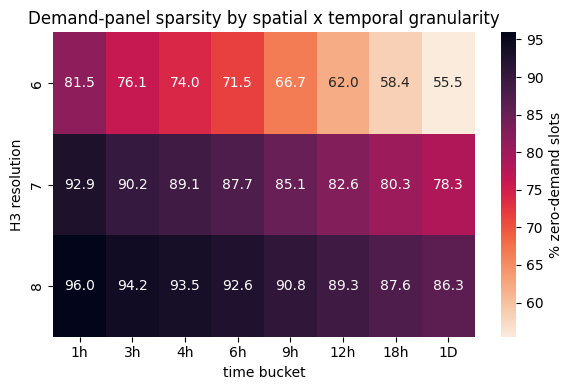

time bucket,1h,3h,4h,6h,9h,12h,18h,1D
H3 resolution,,,,,,,,
6,81.5,76.1,74.0,71.5,66.7,62.0,58.4,55.5
7,92.9,90.2,89.1,87.7,85.1,82.6,80.3,78.3
8,96.0,94.2,93.5,92.6,90.8,89.3,87.6,86.3


In [5]:
import itertools

RES_SWEEP  = [6, 7, 8]
FREQ_SWEEP = ["1h", "3h", "4h", "6h", "9h", "12h", "18h","1D"]

# H3 assignment is the expensive part — do it once per resolution.
for res in RES_SWEEP:
    if f"pickup_h3_r{res}" not in df.columns:
        add_h3_cells(df, res)

# Share of zero-demand (hexagon x bucket) slots for each granularity combo.
zero_grid = pd.DataFrame(index=RES_SWEEP, columns=FREQ_SWEEP, dtype=float)
for res, fr in itertools.product(RES_SWEEP, FREQ_SWEEP):
    p = build_demand_panel(df, resolution=res, freq=fr)
    zero_grid.loc[res, fr] = (p["trip_count"] == 0).mean() * 100
zero_grid.index.name = "H3 resolution"
zero_grid.columns.name = "time bucket"

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(zero_grid, annot=True, fmt=".1f", cmap="rocket_r",
            cbar_kws={"label": "% zero-demand slots"}, ax=ax)
ax.set_title("Demand-panel sparsity by spatial x temporal granularity")
plt.tight_layout()
plt.show()
zero_grid.round(1)

## Panel Features

The calendar and cyclic features are now derived from each bucket's start time (`time_bucket`) rather than per trip, since the model predicts at the *(hexagon, time-bucket)* level. We reuse the same `create_cyclic_features` helper defined above so trip-level and panel-level encodings stay consistent.

The exogenous **weather** features are joined next (see below). Static spatial features (e.g. POI counts per hexagon) and lagged demand (`trip_count` of the same cell 1 / 24 / 168 buckets ago) are added in the respective modelling notebooks, where they can be tailored per model.

### Temporal Features

Ride demand is strongly driven by *when* a trip starts, so we derive calendar features from `trip_start_timestamp` that the later demand models (forecasting trips per spatial unit and time bucket) rely on. The timestamp is already timezone-aware (`America/Chicago`), so every field below is in local Chicago time.

Alongside the basic calendar fields (`hour`, `day_of_week`, `month`, …) we add a US (Illinois) public-holiday flag, since demand on holidays such as Independence Day or Christmas deviates strongly from a normal weekday. Cyclical (sin/cos) encodings — which stop the models from reading hour 23 and hour 0 as far apart — are intentionally **left for the modeling step**, where the encoding can be chosen per model.

All of these features are encapsulated in `preprocess_taxi_data()`, so any notebook calling `load_taxi_data(preprocessed=True)` receives them automatically.

In [6]:
# Calendar features derived from each bucket's start time (tz-aware, local Chicago time).
ts = panel["time_bucket"].dt
panel["hour"]        = ts.hour.astype("Int64")
panel["day_of_week"] = ts.dayofweek.astype("Int64")
panel["month"]       = ts.month.astype("Int64")
panel["is_weekend"]  = ts.dayofweek.isin([5, 6])

# US (Illinois) public-holiday flag (demand differs strongly on holidays).
years = range(int(ts.year.min()), int(ts.year.max()) + 1)
us_il_holidays = holidays.US(subdiv="IL", years=years)
panel["is_holiday"] = panel["time_bucket"].dt.date.isin(set(us_il_holidays))



### Create cyclic Features

We create cyclic features from time-related columns (hour, day of week, month, year) so the model learns their periodic nature instead of treating them as ordinary integers.

**Why cyclic encoding?**

Many calendar variables “wrap around”: 23:00 is close to 00:00, Sunday is close to Monday, and December is close to January. If we keep these as integers, a regression model may interpret the step from 23 → 0 (or 12 → 1) as a large discontinuity, even though the points are neighbors in time. Cyclic encoding fixes this by mapping each value onto a point on the unit circle using sine and cosine, making nearby times have nearby representations.

**How it works (sin & cos pair)**

For a cyclic variable x with period P, we compute:


$$ x_{\sin}=\sin\left(2\pi\frac{x}{P}\right)$$
$$x_{\cos}=\cos\left(2\pi\frac{x}{P}\right)$$



Using both sine and cosine is important: sine alone cannot uniquely represent positions around a circle, while the pair (sin⁡,cos⁡)(sin,cos) preserves the full circular position.


In [7]:
def create_cyclic_features(df):
    df = df.copy()

    # Hour of day
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    # Day of week
    df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    
    # Month of year
    df['month_sin'] = np.sin(2 * np.pi * (df['month'] - 1) / 12)
    df['month_cos'] = np.cos(2 * np.pi * (df['month'] - 1) / 12)
    
    return df

In [8]:
# Cyclic encodings — reuse the helper defined above.
panel = create_cyclic_features(panel)
panel.head()

,h3_id,time_bucket,trip_count,hour,day_of_week,month,is_weekend,is_holiday,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos
0,862664197ffffff,2024-01-01 00:00:00,0,0,0,1,False,True,0.0,1.0,0.0,1.0,0.0,1.0
1,862664197ffffff,2024-01-01 03:00:00,0,3,0,1,False,True,0.707107,0.707107,0.0,1.0,0.0,1.0
2,862664197ffffff,2024-01-01 06:00:00,0,6,0,1,False,True,1.0,0.0,0.0,1.0,0.0,1.0
3,862664197ffffff,2024-01-01 09:00:00,0,9,0,1,False,True,0.707107,-0.707107,0.0,1.0,0.0,1.0
4,862664197ffffff,2024-01-01 12:00:00,0,12,0,1,False,True,0.0,-1.0,0.0,1.0,0.0,1.0


### Weather Features

Weather is an **exogenous** driver of demand (rain and cold shift riders toward taxis) and is available for every hour regardless of whether a trip occurred. We therefore join it **at the panel level** rather than per trip: `add_weather_to_panel` assigns each hexagon to its nearest weather zone (the same k-means centers used elsewhere) and merges the hourly weather on `(zone, time_bucket)`.

Joining here — instead of carrying weather through the trips via `merge_weather` / `load_merged_data` — matters because the **zero-demand rows have no trips** to attach weather to, yet those rainy, empty hours are exactly where weather is most informative. A left join keeps every panel row.

When `FREQ` is coarser than one hour the hourly records are aggregated to the bucket per variable: accumulations (`precipitation`, `rain`, `snowfall`) are **summed**, wind gusts take the **max**, and state variables (temperature, cloud cover, …) are **averaged**.

In [9]:
import json
from scripts.helpers.datasets import load_weather_data, _WEATHER_ZONES_PATH
from scripts.helpers.spatial import add_weather_to_panel

# Hourly weather table + the k-means weather-zone centers (zone -> (lat, lon)).
weather = load_weather_data(preprocessed=True)
with open(_WEATHER_ZONES_PATH) as f:
    weather_zones = {int(k): v for k, v in json.load(f).items()}

# Join weather onto every panel row (zero-demand rows included), aggregated to FREQ.
panel = add_weather_to_panel(panel, weather, weather_zones, freq=FREQ)

added = [c for c in weather.columns if c not in ("time", "zone")]
print(f"Weather columns added: {added}")
print(f"Rows with missing weather: {panel[added].isna().any(axis=1).sum():,}")
panel.head()

Weather columns added: ['temperature_2m', 'apparent_temperature', 'precipitation', 'rain', 'snowfall', 'snow_depth', 'windspeed_10m', 'windgusts_10m', 'cloud_cover']
Rows with missing weather: 0


,h3_id,time_bucket,trip_count,hour,day_of_week,month,is_weekend,is_holiday,hour_sin,hour_cos,...,month_cos,temperature_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,windspeed_10m,windgusts_10m,cloud_cover
0,862664197ffffff,2024-01-01 00:00:00,0,0,0,1,False,True,0.0,1.0,...,1.0,0.466667,-6.333333,0.3,0.0,0.21,0.01,30.300000,45.7,100.000000
1,862664197ffffff,2024-01-01 03:00:00,0,3,0,1,False,True,0.707107,0.707107,...,1.0,0.500000,-5.633333,0.1,0.0,0.07,0.01,25.433333,43.6,100.000000
2,862664197ffffff,2024-01-01 06:00:00,0,6,0,1,False,True,1.0,0.0,...,1.0,-0.933333,-6.833333,0.0,0.0,0.00,0.01,22.566667,33.8,88.333333
3,862664197ffffff,2024-01-01 09:00:00,0,9,0,1,False,True,0.707107,-0.707107,...,1.0,-1.166667,-6.266667,0.0,0.0,0.00,0.01,16.300000,29.5,10.333333
4,862664197ffffff,2024-01-01 12:00:00,0,12,0,1,False,True,0.0,-1.0,...,1.0,0.766667,-4.000000,0.0,0.0,0.00,0.01,13.200000,24.8,26.000000


## Reusing this Pipeline — `prepare_modelling`

Everything above — loading the trips, assigning H3 cells, building the zero-filled demand panel, deriving the calendar and cyclic features, and joining weather — is bundled into a single function, `prepare_modelling(resolution, freq)`, in [`scripts/helpers/modelling.py`](../scripts/helpers/modelling.py). This notebook documents *why* each step exists; the function is the reusable implementation.

The downstream modelling notebooks (e.g. **`05a_svm`** and the neural-network notebook) should **not** repeat these steps. Instead they call:

```python
from scripts.helpers.modelling import prepare_modelling

panel = prepare_modelling(resolution=6, freq="3h")
```

Routing every model through the same function guarantees that the **prediction target (`trip_count`) and the shared feature set are defined identically** across models — so any difference in results comes from the model, not from a divergent panel. Model-specific features (POI counts per hexagon, lagged demand, the chronological train/validation/test split) stay in each modelling notebook, where they can be tailored per model.